===== Data Preparation Results =====
Dataset loaded successfully:
- Total images: 2562
- Number of people: 31
- Image dimension: 100x100 pixels
- Data shape: (2562, 10000)


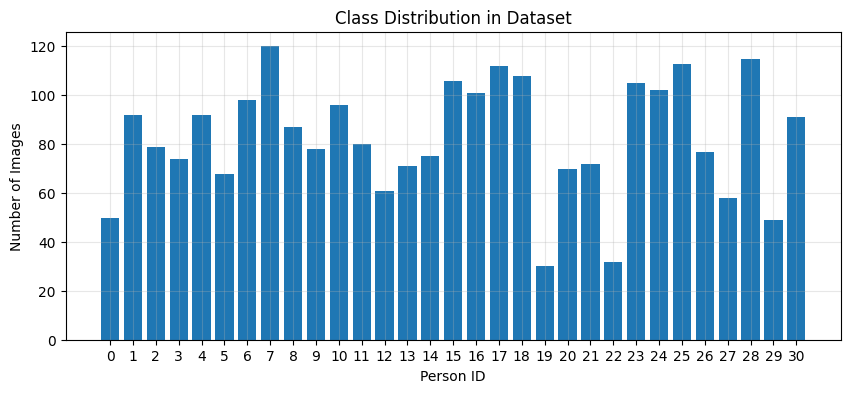

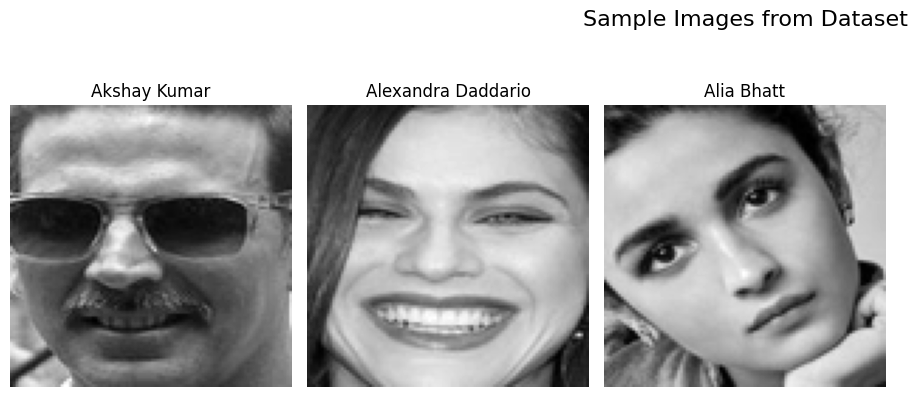


Data split:
- Training set: 2050 images
- Test set: 512 images


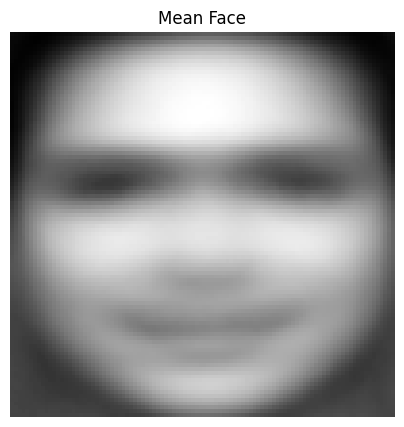

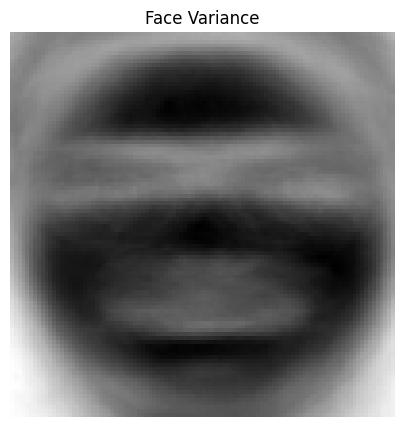

Data preparation completed successfully!


In [53]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Path to dataset
dataset_path = "C:\\Users\\maksm\\PycharmProjects\\FaceRecognition\\archive (1)\\Original Images\\Original Images"

# Load images with consistent dimensions
def load_images(dataset_path, target_size=(100, 100)):
    images = []
    labels = []
    label_dict = {}
    person_names = set()

    # First pass to identify all unique person names
    for img_file in os.listdir(dataset_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Extract person name from filename (assuming format: person_name_number.jpg)
            person_name = img_file.split('_')[0]
            person_names.add(person_name)

    # Create label mapping
    for i, name in enumerate(sorted(person_names)):
        label_dict[i] = name

    # Second pass to load images with proper labels
    for img_file in os.listdir(dataset_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            try:
                img_path = os.path.join(dataset_path, img_file)
                person_name = img_file.split('_')[0]

                # Find the label for this person
                person_id = [k for k, v in label_dict.items() if v == person_name][0]

                # Load and process the image
                img = Image.open(img_path).convert('L')  # Convert to grayscale
                img = img.resize(target_size)  # Resize to consistent dimensions
                img_array = np.array(img).flatten()  # Flatten to 1D array

                images.append(img_array)
                labels.append(person_id)
            except Exception as e:
                print(f"Error loading {img_file}: {e}")

    return np.array(images), np.array(labels), label_dict
def preprocess_images(X_train, X_test):
    # Normalize pixel values to [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    X_train = (X_train - np.mean(X_train, axis=1, keepdims=True)) / (np.std(X_train, axis=1, keepdims=True) + 1e-7)
    X_test = (X_test - np.mean(X_test, axis=1, keepdims=True)) / (np.std(X_test, axis=1, keepdims=True) + 1e-7)

    # # Standardization (zero mean, unit variance)
    # mean = np.mean(X_train, axis=0)
    # std = np.std(X_train, axis=0) + 1e-7
    # X_train = (X_train - mean) / std
    # X_test = (X_test - mean) / std

    return X_train, X_test

# Split dataset function
def split_dataset(images, labels, test_ratio=0.2):
    np.random.seed(42)
    indices = np.random.permutation(len(images))
    test_size = int(len(images) * test_ratio)

    test_indices = indices[:test_size]
    train_indices = indices[test_size:]

    X_train = images[train_indices]
    y_train = labels[train_indices]
    X_test = images[test_indices]
    y_test = labels[test_indices]

    return X_train, y_train, X_test, y_test

# Load dataset with consistent dimensions
# X, y, label_dict = load_images(dataset_path)

# Now visualize the data preparation
def visualize_data_preparation(X, y):
    print("===== Data Preparation Results =====")

    # 1. Basic dataset statistics
    n_samples = len(X)
    n_classes = len(np.unique(y))
    img_dim = int(np.sqrt(X.shape[1]))

    print(f"Dataset loaded successfully:")
    print(f"- Total images: {n_samples}")
    print(f"- Number of people: {n_classes}")
    print(f"- Image dimension: {img_dim}x{img_dim} pixels")
    print(f"- Data shape: {X.shape}")

    # 2. Show class distribution
    unique_classes, class_counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(10, 4))
    plt.bar(unique_classes, class_counts)
    plt.xlabel("Person ID")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution in Dataset")
    plt.xticks(unique_classes)
    plt.grid(alpha=0.3)
    plt.show()

    # 3. Show sample images from each class
    plt.figure(figsize=(15, 8))
    plt.suptitle("Sample Images from Dataset", fontsize=16)

    for i, class_id in enumerate(unique_classes[:3]):  # Limit to first 10 classes
        class_images = X[y == class_id]

        if len(class_images) > 0:
            # Show first image of each class
            plt.subplot(2, 5, i+1)
            plt.imshow(class_images[0].reshape(img_dim, img_dim), cmap='gray')
            plt.title(f"{label_dict[class_id]}" if class_id in label_dict else f"Person {class_id}")
            plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

    # 4. Show data splits
    X_train, y_train, X_test, y_test = split_dataset(X, y)

    print("\nData split:")
    print(f"- Training set: {len(X_train)} images")
    print(f"- Test set: {len(X_test)} images")

    # 5. Show mean face
    mean_face = np.mean(X_train, axis=0)
    plt.figure(figsize=(5, 5))
    plt.imshow(mean_face.reshape(img_dim, img_dim), cmap='gray')
    plt.title("Mean Face")
    plt.axis('off')
    plt.show()

    # 6. Show face variance
    std_face = np.std(X_train, axis=0)
    plt.figure(figsize=(5, 5))
    plt.imshow(std_face.reshape(img_dim, img_dim), cmap='gray')
    plt.title("Face Variance")
    plt.axis('off')
    plt.show()

    return X_train, y_train, X_test, y_test

# Try to visualize the data
try:
    X_train, y_train, X_test, y_test = visualize_data_preparation(X, y)
    print("Data preparation completed successfully!")
except Exception as e:
    print(f"Error during data preparation: {e}")

dataset_path = "C:\\Users\\maksm\\PycharmProjects\\FaceRecognition\\archive (1)\\Faces\\Faces"
X, y, label_dict = load_images(dataset_path)
X_train, y_train, X_test, y_test = split_dataset(X, y)


In [54]:
def pca_from_scratch(X, n_components, regularization=1e-6):
    """
    Implementation of Principal Component Analysis from scratch with regularization.

    Args:
        X: Input data matrix of shape (n_samples, n_features)
        n_components: Number of principal components to keep
        regularization: Small value to add to diagonal of covariance matrix

    Returns:
        projected: Data projected onto principal components
        eigenvectors: Principal component vectors
        eigenvalues: Corresponding eigenvalues
        mean_face: Mean of the input data
        explained_variance: Proportion of variance explained by each component
    """
    # Center data
    mean_face = np.mean(X, axis=0)
    X_centered = X - mean_face

    # Compute covariance matrix
    n_samples = X_centered.shape[0]

    # Use the trick for high-dimensional data: X·Xᵀ instead of Xᵀ·X
    if X_centered.shape[1] > n_samples:
        cov_small = np.dot(X_centered, X_centered.T) / (n_samples - 1)
        # Add regularization to avoid numerical instability
        cov_small += np.eye(cov_small.shape[0]) * regularization

        # Get eigenvectors and eigenvalues
        eigenvalues_small, eigenvectors_small = np.linalg.eigh(cov_small)

        # Sort eigenvectors by decreasing eigenvalues
        idx = np.argsort(eigenvalues_small)[::-1]
        eigenvalues_small = eigenvalues_small[idx]
        eigenvectors_small = eigenvectors_small[:, idx]

        # Convert eigenvectors from small covariance matrix to large one
        eigenvectors = np.dot(X_centered.T, eigenvectors_small)

        # Normalize eigenvectors
        for i in range(eigenvectors.shape[1]):
            eigenvectors[:, i] = eigenvectors[:, i] / np.linalg.norm(eigenvectors[:, i])

        # Use eigenvalues from small matrix
        eigenvalues = eigenvalues_small
    else:
        # Direct computation for lower-dimensional data
        cov = np.dot(X_centered.T, X_centered) / (n_samples - 1)
        # Add regularization to avoid numerical instability
        cov += np.eye(cov.shape[0]) * regularization

        # Get eigenvectors and eigenvalues
        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        # Sort eigenvectors by decreasing eigenvalues
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

    # Limit number of components (handle case where n_components > min dimension)
    max_components = min(n_components, X.shape[0], X.shape[1])
    eigenvectors = eigenvectors[:, :max_components]
    eigenvalues = eigenvalues[:max_components]

    # Project data onto eigenspace
    projected = np.dot(X_centered, eigenvectors)

    # Calculate explained variance ratio
    total_var = np.sum(eigenvalues)
    explained_variance = eigenvalues / total_var if total_var > 0 else np.zeros_like(eigenvalues)

    return projected, eigenvectors, eigenvalues, mean_face, explained_variance

Testing PCA accuracy with different component counts...
Components:   5 | Accuracy: 0.1953 | Time: 2.78s
Components:  10 | Accuracy: 0.3516 | Time: 2.84s
Components:  15 | Accuracy: 0.4492 | Time: 2.87s
Components:  20 | Accuracy: 0.5176 | Time: 2.89s
Components:  25 | Accuracy: 0.5547 | Time: 2.91s
Components:  30 | Accuracy: 0.5840 | Time: 3.14s
Components:  35 | Accuracy: 0.5938 | Time: 2.83s
Components:  40 | Accuracy: 0.6016 | Time: 3.04s
Components:  45 | Accuracy: 0.6074 | Time: 2.97s
Components:  50 | Accuracy: 0.6191 | Time: 3.01s
Components:  55 | Accuracy: 0.6152 | Time: 3.00s
Components:  60 | Accuracy: 0.6230 | Time: 4.02s
Components:  65 | Accuracy: 0.6211 | Time: 2.99s
Components:  70 | Accuracy: 0.6152 | Time: 3.06s
Components:  75 | Accuracy: 0.6152 | Time: 3.08s
Components:  80 | Accuracy: 0.6250 | Time: 3.02s
Components:  85 | Accuracy: 0.6250 | Time: 2.97s
Components:  90 | Accuracy: 0.6270 | Time: 3.23s
Components:  95 | Accuracy: 0.6250 | Time: 2.99s


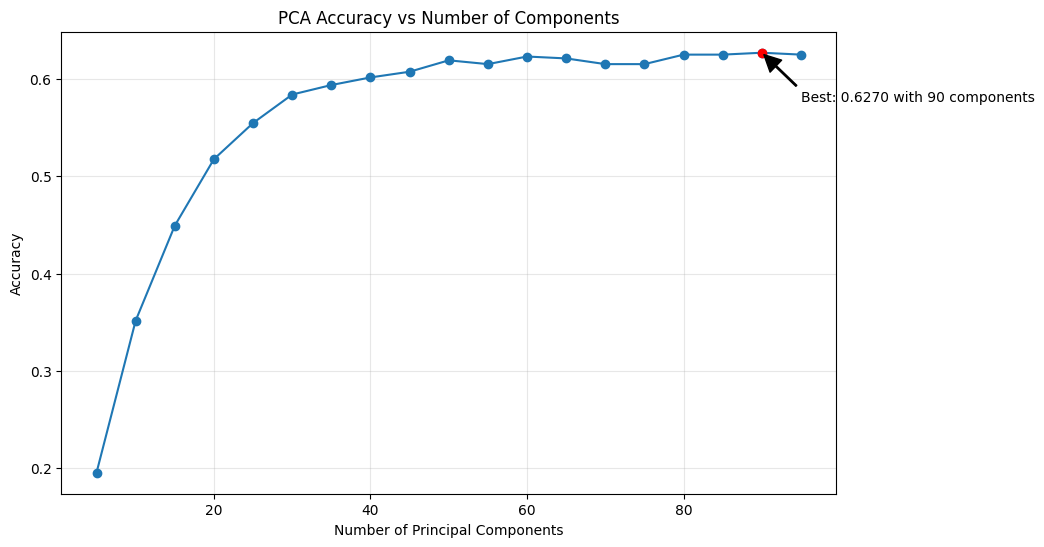


Best accuracy: 0.6270 with 90 components


In [55]:
def test_pca_accuracy(X_train, y_train, X_test, y_test, max_components=100, step=5):
    """
    Test PCA accuracy for face recognition across different component counts.

    Args:
        X_train, y_train: Training data
        X_test, y_test: Testing data
        max_components: Maximum number of components to test
        step: Step size between component counts

    Returns:
        Dictionary with component counts and corresponding accuracies
    """
    from sklearn.svm import SVC
    import time

    # Preprocess data
    X_train_proc, X_test_proc = preprocess_images(X_train, X_test)

    # Store results
    results = {'components': [], 'accuracy': [], 'time': []}

    # Test different numbers of components
    component_counts = list(range(5, min(max_components, X_train.shape[0]), step))
    best_accuracy = 0
    best_components = 0

    print("Testing PCA accuracy with different component counts...")

    for n_components in component_counts:
        start_time = time.time()

        # Perform PCA
        pca_projected, pca_components, _, _, _ = pca_from_scratch(X_train_proc, n_components)

        # Project test data
        X_test_centered = X_test_proc - np.mean(X_train_proc, axis=0)
        pca_test = np.dot(X_test_centered, pca_components)

        # Train classifier
        classifier = SVC(kernel='rbf', C=10, gamma='scale')
        classifier.fit(pca_projected, y_train)

        # Predict and evaluate
        y_pred = classifier.predict(pca_test)
        accuracy = np.mean(y_pred == y_test)

        duration = time.time() - start_time

        # Record results
        results['components'].append(n_components)
        results['accuracy'].append(accuracy)
        results['time'].append(duration)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_components = n_components

        print(f"Components: {n_components:3d} | Accuracy: {accuracy:.4f} | Time: {duration:.2f}s")

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(results['components'], results['accuracy'], marker='o')
    plt.title('PCA Accuracy vs Number of Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)

    # Add best point annotation
    plt.plot(best_components, best_accuracy, 'ro')
    plt.annotate(f"Best: {best_accuracy:.4f} with {best_components} components",
                xy=(best_components, best_accuracy),
                xytext=(best_components+5, best_accuracy-0.05),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1))

    plt.show()

    print(f"\nBest accuracy: {best_accuracy:.4f} with {best_components} components")

    return results

# Run the accuracy test
pca_results = test_pca_accuracy(X_train, y_train, X_test, y_test,
                               max_components=100, step=5)

In [56]:
def lda_from_scratch(X, y, n_components):
    """
    Fast LDA implementation for high-dimensional data.

    Args:
        X: Input data (n_samples, n_features)
        y: Class labels (n_samples,)
        n_components: Number of components to keep

    Returns:
        projected_data: Data projected onto LDA space
        components: LDA components/vectors
        eigenvalues: Corresponding eigenvalues
    """
    from scipy import linalg
    import numpy as np

    # Get unique classes and counts
    classes = np.unique(y)
    n_classes = len(classes)
    n_samples, n_features = X.shape

    # Compute global mean
    global_mean = np.mean(X, axis=0)
    X_centered = X - global_mean

    # Initialize scatter matrices
    sw = np.zeros((X.shape[1], X.shape[1]))
    sb = np.zeros_like(sw)

    # Compute between-class and within-class scatter matrices (vectorized)
    class_means = []
    class_counts = []

    # Calculate means and counts in one pass
    for c in classes:
        class_mask = (y == c)
        class_data = X[class_mask]
        n_class_samples = class_data.shape[0]

        class_mean = np.mean(class_data, axis=0)
        class_means.append(class_mean)
        class_counts.append(n_class_samples)

        # Between-class scatter
        mean_diff = class_mean - global_mean
        sb += n_class_samples * np.outer(mean_diff, mean_diff)

        # Within-class scatter - use vectorized operations
        class_centered = class_data - class_mean
        sw += np.dot(class_centered.T, class_centered)

    # Add regularization to within-class scatter matrix
    sw += np.eye(sw.shape[0]) * 1e-4

    # Solve generalized eigenvalue problem (S_b * w = lambda * S_w * w)
    try:
        eigenvalues, eigenvectors = linalg.eigh(sb, sw)
    except np.linalg.LinAlgError:
        # If still singular, add more regularization
        sw += np.eye(sw.shape[0]) * 1e-2
        eigenvalues, eigenvectors = linalg.eigh(sb, sw)

    # Sort eigenvalues in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Limit to n_components (cannot exceed n_classes - 1)
    max_components = min(n_components, n_classes - 1, eigenvectors.shape[1])
    eigenvectors = eigenvectors[:, :max_components]
    eigenvalues = eigenvalues[:max_components]

    # Project the data onto LDA components
    projected_data = np.dot(X_centered, eigenvectors)

    return projected_data, eigenvectors, eigenvalues# Test LDA function
try:
    n_components_lda = 2
    projected_lda, eigenvectors_lda, eigenvalues_lda = lda_from_scratch(projected, y_train, n_components_lda)

    print(f"LDA completed successfully with {n_components_lda} components!")
    print(f"Projected LDA shape: {projected_lda.shape}")
    print(f"Eigenvalues LDA shape: {eigenvalues_lda.shape}")
    print(f"Eigenvectors LDA shape: {eigenvectors_lda.shape}")
except Exception as e:
    print(f"Error during LDA: {e}")

LDA completed successfully with 2 components!
Projected LDA shape: (2050, 2)
Eigenvalues LDA shape: (2,)
Eigenvectors LDA shape: (10, 2)



Testing with 75x75 images:
Image size: 75x75 | PCA components: 100 | LDA components: 20
Accuracy: 0.5859 | Time: 2.82s

Testing with 50x50 images:
Image size: 50x50 | PCA components: 100 | LDA components: 20
Accuracy: 0.5801 | Time: 2.24s

Testing with 32x32 images:
Image size: 32x32 | PCA components: 100 | LDA components: 20
Accuracy: 0.5801 | Time: 0.81s

Testing with 25x25 images:
Image size: 25x25 | PCA components: 100 | LDA components: 20
Accuracy: 0.5723 | Time: 0.55s


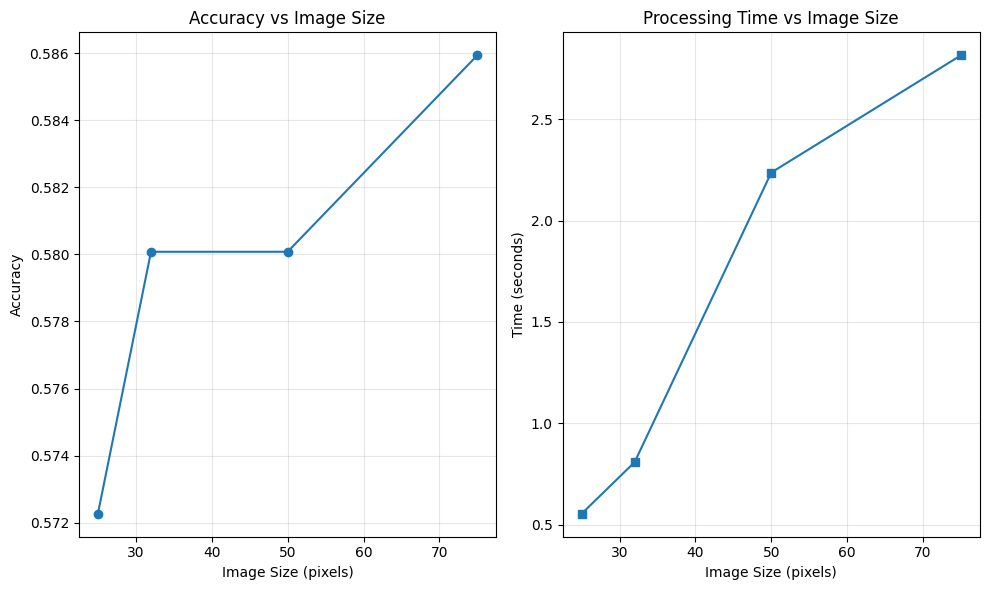

In [57]:
def test_lda_with_reduced_dimensions(X_train, y_train, X_test, y_test):
    """Test LDA accuracy with reduced image dimensions."""
    from sklearn.svm import SVC
    import time

    # Reshape to image format
    img_size = int(np.sqrt(X_train.shape[1]))
    X_train_img = X_train.reshape(-1, img_size, img_size)
    X_test_img = X_test.reshape(-1, img_size, img_size)

    # Try different reduced dimensions
    reduced_sizes = [75, 50, 32, 25]
    results = {}

    for size in reduced_sizes:
        print(f"\nTesting with {size}x{size} images:")

        # Resize images
        X_train_resized = np.array([np.array(Image.fromarray(img).resize((size, size), Image.LANCZOS)).flatten()
                                  for img in X_train_img])
        X_test_resized = np.array([np.array(Image.fromarray(img).resize((size, size), Image.LANCZOS)).flatten()
                                 for img in X_test_img])

        # Standardize
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_resized)
        X_test_scaled = scaler.transform(X_test_resized)

        # Apply PCA first to reduce dimensions further
        n_classes = len(np.unique(y_train))
        pca_components = min(100, X_train_scaled.shape[0] - n_classes)

        start_time = time.time()
        pca_projected, pca_components_mat, _, mean_face, _ = pca_from_scratch(
            X_train_scaled, pca_components, regularization=1e-4
        )

        # Project test data
        X_test_centered = X_test_scaled - mean_face
        X_test_pca = np.dot(X_test_centered, pca_components_mat)

        # Apply LDA
        n_components_lda = min(20, n_classes-1)
        lda_projected, lda_components, _ = lda_from_scratch(pca_projected, y_train, n_components_lda)

        # Project test data
        X_test_lda = np.dot(X_test_pca, lda_components)

        # Train classifier
        classifier = SVC(kernel='rbf', C=10, gamma='scale')
        classifier.fit(lda_projected, y_train)

        # Evaluate
        y_pred = classifier.predict(X_test_lda)
        accuracy = np.mean(y_pred == y_test)

        duration = time.time() - start_time

        print(f"Image size: {size}x{size} | PCA components: {pca_components} | LDA components: {n_components_lda}")
        print(f"Accuracy: {accuracy:.4f} | Time: {duration:.2f}s")

        results[size] = {
            'accuracy': accuracy,
            'time': duration,
            'dimensions': size*size,
            'pca_components': pca_components,
            'lda_components': n_components_lda
        }

    # Plot results
    plt.figure(figsize=(10, 6))
    sizes = list(results.keys())
    accuracies = [results[s]['accuracy'] for s in sizes]
    times = [results[s]['time'] for s in sizes]

    plt.subplot(1, 2, 1)
    plt.plot(sizes, accuracies, marker='o')
    plt.title('Accuracy vs Image Size')
    plt.xlabel('Image Size (pixels)')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(sizes, times, marker='s')
    plt.title('Processing Time vs Image Size')
    plt.xlabel('Image Size (pixels)')
    plt.ylabel('Time (seconds)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results

# Run test with different image sizes
image_size_results = test_lda_with_reduced_dimensions(X_train, y_train, X_test, y_test)

In [58]:
# def test_lda_vs_pcalda_accuracy(X_train, y_train, X_test, y_test, max_pca_components=100, step=10):
#     """
#     Tests and compares standalone LDA vs PCA+LDA across different component configurations.
#
#     Args:
#         X_train, y_train: Training data
#         X_test, y_test: Testing data
#         max_pca_components: Maximum number of PCA components to test
#         step: Step size between component counts
#
#     Returns:
#         Dictionary with results for both methods
#     """
#     from sklearn.svm import SVC
#     import time
#     import numpy as np
#
#     # Preprocess data
#     X_train_proc, X_test_proc = preprocess_images(X_train, X_test)
#
#     # Get number of classes and max possible LDA components
#     n_classes = len(np.unique(y_train))
#     max_lda_components = min(n_classes - 1, X_train_proc.shape[1])
#
#     results = {
#         'lda_only': {
#             'components': [],
#             'accuracy': [],
#             'time': []
#         },
#         'pca_lda': {
#             'pca_components': [],
#             'lda_components': [],
#             'accuracy': [],
#             'time': []
#         }
#     }
#
#     print("=== Testing LDA Only ===")
#
#     # 1. Test LDA directly on raw data with different component counts
#     for n_components in range(1, max_lda_components + 1):
#         start_time = time.time()
#
#         try:
#             # Apply LDA directly to preprocessed data
#             lda_projected, lda_components, _ = lda_from_scratch(X_train_proc, y_train, n_components)
#
#             # Project test data
#             lda_test = np.dot(X_test_proc, lda_components)
#
#             # Train classifier
#             classifier = SVC(kernel='rbf', C=10, gamma='scale')
#             classifier.fit(lda_projected, y_train)
#
#             # Predict and evaluate
#             y_pred = classifier.predict(lda_test)
#             accuracy = np.mean(y_pred == y_test)
#
#             duration = time.time() - start_time
#
#             # Record results
#             results['lda_only']['components'].append(n_components)
#             results['lda_only']['accuracy'].append(accuracy)
#             results['lda_only']['time'].append(duration)
#
#             print(f"LDA components: {n_components:3d} | Accuracy: {accuracy:.4f} | Time: {duration:.2f}s")
#
#         except np.linalg.LinAlgError as e:
#             print(f"Error with LDA {n_components} components: {e}")
#             # If LDA fails due to singularity, we'll skip this component count
#             continue
#
#     print("\n=== Testing PCA+LDA ===")
#
#     # 2. Test PCA+LDA with different component configurations
#     best_pca_lda_accuracy = 0
#     best_config = None
#
#     pca_ranges = list(range(n_classes, min(max_pca_components, X_train.shape[0]), step))
#     if not pca_ranges or pca_ranges[0] > n_classes:
#         # Ensure we have at least the minimum needed for LDA
#         pca_ranges = [n_classes] + pca_ranges
#
#     for n_pca_components in pca_ranges:
#         # First perform PCA
#         pca_projected, pca_components, _, mean_face, _ = pca_from_scratch(
#             X_train_proc, n_pca_components, regularization=1e-6
#         )
#
#         # Project test data onto PCA components
#         X_test_centered = X_test_proc - mean_face
#         pca_test = np.dot(X_test_centered, pca_components)
#
#         # The maximum number of LDA components is min(n_pca_components, n_classes-1)
#         max_lda_for_pca = min(n_pca_components, n_classes - 1)
#
#         for n_lda_components in range(1, max_lda_for_pca + 1):
#             start_time = time.time()
#
#             try:
#                 # Perform LDA on PCA-projected data
#                 lda_projected, lda_components, _ = lda_from_scratch(
#                     pca_projected, y_train, n_lda_components
#                 )
#
#                 # Project test data
#                 lda_test = np.dot(pca_test, lda_components)
#
#                 # Train classifier
#                 classifier = SVC(kernel='rbf', C=10, gamma='scale')
#                 classifier.fit(lda_projected, y_train)
#
#                 # Predict and evaluate
#                 y_pred = classifier.predict(lda_test)
#                 accuracy = np.mean(y_pred == y_test)
#
#                 duration = time.time() - start_time
#
#                 # Record results
#                 results['pca_lda']['pca_components'].append(n_pca_components)
#                 results['pca_lda']['lda_components'].append(n_lda_components)
#                 results['pca_lda']['accuracy'].append(accuracy)
#                 results['pca_lda']['time'].append(duration)
#
#                 # Track best configuration
#                 if accuracy > best_pca_lda_accuracy:
#                     best_pca_lda_accuracy = accuracy
#                     best_config = (n_pca_components, n_lda_components)
#
#                 print(f"PCA: {n_pca_components:3d}, LDA: {n_lda_components:3d} | Accuracy: {accuracy:.4f} | Time: {duration:.2f}s")
#
#             except Exception as e:
#                 print(f"Error with PCA {n_pca_components}, LDA {n_lda_components}: {e}")
#                 continue
#
#     # Plot results
#     plt.figure(figsize=(12, 5))
#
#     plt.subplot(1, 2, 1)
#     if results['lda_only']['components']:
#         plt.plot(results['lda_only']['components'], results['lda_only']['accuracy'], marker='o')
#         plt.title('LDA Only Accuracy vs Components')
#         plt.xlabel('Number of LDA Components')
#         plt.ylabel('Accuracy')
#         plt.grid(True, alpha=0.3)
#     else:
#         plt.text(0.5, 0.5, 'No LDA results available\n(likely due to singular matrices)',
#                 ha='center', va='center')
#         plt.title('LDA Only (Failed)')
#
#     plt.subplot(1, 2, 2)
#     # Create a scatter plot with point size reflecting accuracy
#     if results['pca_lda']['pca_components']:
#         plt.scatter(
#             results['pca_lda']['pca_components'],
#             results['pca_lda']['lda_components'],
#             c=results['pca_lda']['accuracy'],
#             cmap='viridis',
#             s=100,
#             alpha=0.7
#         )
#
#         plt.colorbar(label='Accuracy')
#         plt.title('PCA+LDA Accuracy')
#         plt.xlabel('PCA Components')
#         plt.ylabel('LDA Components')
#
#         # Mark best configuration
#         if best_config:
#             plt.plot(best_config[0], best_config[1], 'r*', markersize=15)
#             plt.annotate(f"Best: {best_pca_lda_accuracy:.4f}",
#                         xy=(best_config[0], best_config[1]),
#                         xytext=(best_config[0]+5, best_config[1]+1),
#                         fontweight='bold')
#     else:
#         plt.text(0.5, 0.5, 'No PCA+LDA results available',
#                 ha='center', va='center')
#         plt.title('PCA+LDA (No Results)')
#
#     plt.tight_layout()
#     plt.show()
#
#     # Compare the best results from each method
#     if results['lda_only']['accuracy'] and results['pca_lda']['accuracy']:
#         best_lda_idx = np.argmax(results['lda_only']['accuracy'])
#         best_lda_only = {
#             'components': results['lda_only']['components'][best_lda_idx],
#             'accuracy': results['lda_only']['accuracy'][best_lda_idx]
#         }
#
#         best_pca_lda_idx = np.argmax(results['pca_lda']['accuracy'])
#         best_pca_lda = {
#             'pca_components': results['pca_lda']['pca_components'][best_pca_lda_idx],
#             'lda_components': results['pca_lda']['lda_components'][best_pca_lda_idx],
#             'accuracy': results['pca_lda']['accuracy'][best_pca_lda_idx]
#         }
#
#         print("\n=== Best Configurations ===")
#         print(f"LDA Only: {best_lda_only['accuracy']:.4f} with {best_lda_only['components']} components")
#         print(f"PCA+LDA: {best_pca_lda['accuracy']:.4f} with {best_pca_lda['pca_components']} PCA components and {best_pca_lda['lda_components']} LDA components")
#
#         # Create a bar chart comparing the methods
#         plt.figure(figsize=(8, 5))
#         methods = ['LDA Only', 'PCA+LDA']
#         accuracies = [best_lda_only['accuracy'], best_pca_lda['accuracy']]
#         plt.bar(methods, accuracies, color=['skyblue', 'orange'])
#         plt.ylim(0, 1.0)
#         plt.title('Comparison of Best Configurations')
#         plt.ylabel('Accuracy')
#
#         # Add value labels on bars
#         for i, acc in enumerate(accuracies):
#             plt.text(i, acc + 0.02, f"{acc:.4f}", ha='center')
#
#         # Add component information below bars
#         plt.annotate(f"{best_lda_only['components']} components",
#                     xy=(0, 0), xytext=(0, -0.05),
#                     ha='center', xycoords=('data', 'axes fraction'))
#
#         plt.annotate(f"{best_pca_lda['pca_components']} PCA → {best_pca_lda['lda_components']} LDA",
#                     xy=(1, 0), xytext=(1, -0.05),
#                     ha='center', xycoords=('data', 'axes fraction'))
#
#         plt.grid(axis='y', alpha=0.3)
#         plt.tight_layout()
#         plt.show()
#
#     return results
#
# # Run the comparison test
# lda_vs_pcalda_results = test_lda_vs_pcalda_accuracy(X_train, y_train, X_test, y_test, max_pca_components=100, step=10)

In [67]:
def svd_from_scratch(X, n_components):
    """
    Implementation of SVD from scratch with numerical stability improvements.

    Args:
        X: Input data matrix
        n_components: Number of components to keep

    Returns:
        projected: Data projected onto components
        V: Right singular vectors
        singular_values: Singular values
        mean_face: Mean of input data
    """
    # Center data
    mean_face = np.mean(X, axis=0)
    X_centered = X - mean_face

    # Use the trick for high-dimensional data to compute XᵀX
    n_samples = X_centered.shape[0]

    # Compute covariance matrix (XᵀX)
    cov = np.dot(X_centered.T, X_centered) / (n_samples - 1)

    # Add small regularization to ensure positive eigenvalues
    cov += np.eye(cov.shape[0]) * 1e-12

    # Get eigenvectors and eigenvalues
    eigenvalues, V = np.linalg.eigh(cov)

    # Sort by decreasing eigenvalues
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    V = V[:, idx]

    # Replace any negative eigenvalues (due to numerical errors) with 0
    eigenvalues = np.maximum(eigenvalues, 0)

    # Compute singular values (sqrt of eigenvalues)
    singular_values = np.sqrt(eigenvalues)

    # Limit number of components
    max_components = min(n_components, len(singular_values))
    V = V[:, :max_components]
    singular_values = singular_values[:max_components]

    # Project data
    projected = np.dot(X_centered, V)

    return projected, V, singular_values, mean_face
# Test SVD function
try:
    n_components_svd = 10
    projected_svd, V_svd, singular_values_svd, mean_face_svd = svd_from_scratch(X_train, n_components_svd)

    print(f"SVD completed successfully with {n_components_svd} components!")
    print(f"Projected SVD shape: {projected_svd.shape}")
    print(f"Singular values shape: {singular_values_svd.shape}")
    print(f"V shape: {V_svd.shape}")
    print(f"Mean face shape: {mean_face_svd.shape}")
except Exception as e:
    print(f"Error during SVD: {e}")


SVD completed successfully with 10 components!
Projected SVD shape: (2050, 10)
Singular values shape: (10,)
V shape: (10000, 10)
Mean face shape: (10000,)


In [68]:
def nmf_from_scratch(X, n_components, max_iter=100, tol=1e-4):
    # Ensure non-negativity
    X = np.maximum(X, 0)

    # Initialize W and H with random values
    np.random.seed(42)
    n_samples, n_features = X.shape
    W = np.random.rand(n_samples, n_components)
    H = np.random.rand(n_components, n_features)

    # Iterative update
    for i in range(max_iter):
        # Update H
        numerator = np.dot(W.T, X)
        denominator = np.dot(np.dot(W.T, W), H)
        denominator[denominator == 0] = 1e-10  # Avoid division by zero
        H *= numerator / denominator

        # Update W
        numerator = np.dot(X, H.T)
        denominator = np.dot(W, np.dot(H, H.T))
        denominator[denominator == 0] = 1e-10  # Avoid division by zero
        W *= numerator / denominator

        # Check convergence
        error = np.linalg.norm(X - np.dot(W, H), 'fro')
        if i > 0 and abs(prev_error - error) < tol:
            break
        prev_error = error

    return W, H
# Test NMF function
try:
    n_components_nmf = 10
    W_nmf, H_nmf = nmf_from_scratch(X_train, n_components_nmf)

    print(f"NMF completed successfully with {n_components_nmf} components!")
    print(f"W shape: {W_nmf.shape}")
    print(f"H shape: {H_nmf.shape}")
except Exception as e:
    print(f"Error during NMF: {e}")


NMF completed successfully with 10 components!
W shape: (2050, 10)
H shape: (10, 10000)


In [69]:
class SVM_Scratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Convert class labels to -1 and 1
        y_ = np.where(y <= 0, -1, 1)

        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) + self.b) >= 1

                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

        return self

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)

# Test SVM function
try:
    svm_model = SVM_Scratch()
    svm_model.fit(X_train, y_train)
    predictions = svm_model.predict(X_test)

    print("SVM completed successfully!")
    print(f"Predictions shape: {predictions.shape}")
    print(f"Predictions: {predictions[:10]}")
except Exception as e:
    print(f"Error during SVM: {e}")

SVM completed successfully!
Predictions shape: (512,)
Predictions: [ 1.  1.  1.  1.  1.  1. -1.  1.  1.  1.]


In [70]:
def evaluate_model(y_true, y_pred):
    accuracy = np.sum(y_true == y_pred) / len(y_true)

    # Calculate per-class metrics
    classes = np.unique(y_true)
    precision_per_class = {}
    recall_per_class = {}
    f1_per_class = {}

    for c in classes:
        true_positives = np.sum((y_true == c) & (y_pred == c))
        false_positives = np.sum((y_true != c) & (y_pred == c))
        false_negatives = np.sum((y_true == c) & (y_pred != c))

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        precision_per_class[c] = precision
        recall_per_class[c] = recall
        f1_per_class[c] = f1

    avg_precision = np.mean(list(precision_per_class.values()))
    avg_recall = np.mean(list(recall_per_class.values()))
    avg_f1 = np.mean(list(f1_per_class.values()))

    return {
        'accuracy': accuracy,
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': avg_f1,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'f1_per_class': f1_per_class
    }

def run_pipeline(X_train, y_train, X_test, y_test):
    results = {}

    # PCA only
    n_components_pca = 50
    pca_projected, pca_components, _, _ = pca_from_scratch(X_train, n_components_pca)
    pca_test = np.dot(X_test - np.mean(X_train, axis=0), pca_components)

    svm_pca = MultiClassSVM()
    svm_pca.fit(pca_projected, y_train)
    pca_preds = svm_pca.predict(pca_test)
    results['PCA'] = evaluate_model(y_test, pca_preds)

    # PCA + LDA
    n_components_lda = min(n_components_pca, len(np.unique(y_train)) - 1)
    lda_projected, lda_components, _, = lda_from_scratch(pca_projected, y_train, n_components_lda)
    lda_test = np.dot(pca_test, lda_components)

    svm_lda = MultiClassSVM()
    svm_lda.fit(lda_projected, y_train)
    lda_preds = svm_lda.predict(lda_test)
    results['PCA+LDA'] = evaluate_model(y_test, lda_preds)

    # SVD
    svd_projected, svd_components, _, _ = svd_from_scratch(X_train, n_components_pca)
    svd_test = np.dot(X_test - np.mean(X_train, axis=0), svd_components)

    svm_svd = MultiClassSVM()
    svm_svd.fit(svd_projected, y_train)
    svd_preds = svm_svd.predict(svd_test)
    results['SVD'] = evaluate_model(y_test, svd_preds)

    # SVD + LDA
    svd_lda_projected, svd_lda_components, _ = lda_from_scratch(svd_projected, y_train, n_components_lda)
    svd_lda_test = np.dot(svd_test, svd_lda_components)

    svm_svd_lda = MultiClassSVM()
    svm_svd_lda.fit(svd_lda_projected, y_train)
    svd_lda_preds = svm_svd_lda.predict(svd_lda_test)
    results['SVD+LDA'] = evaluate_model(y_test, svd_lda_preds)

    # NMF features
    X_train_pos = np.maximum(X_train - np.min(X_train), 0)  # Ensure non-negativity
    W_train, H = nmf_from_scratch(X_train_pos, n_components=30)

    X_test_pos = np.maximum(X_test - np.min(X_train), 0)
    W_test = np.dot(X_test_pos, np.linalg.pinv(H))

    svm_nmf = MultiClassSVM()
    svm_nmf.fit(W_train, y_train)
    nmf_preds = svm_nmf.predict(W_test)
    results['NMF'] = evaluate_model(y_test, nmf_preds)

    return results


In [71]:
def train_cnn(X_train, y_train, X_test, y_test, epochs=20):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.utils import to_categorical

    # Reshape data
    img_dim = int(np.sqrt(X_train.shape[1]))
    X_train_cnn = X_train.reshape(-1, img_dim, img_dim, 1)
    X_test_cnn = X_test.reshape(-1, img_dim, img_dim, 1)

    # One-hot encode
    n_classes = len(np.unique(y_train))
    y_train_cnn = to_categorical(y_train, n_classes)
    y_test_cnn = to_categorical(y_test, n_classes)

    # Build model with batch normalization
    model = Sequential([
        Conv2D(64, (3, 3), padding='same', activation='relu', input_shape=(img_dim, img_dim, 1)),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        Conv2D(256, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(n_classes, activation='softmax')
    ])

    # Compile with better optimization
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    reduce_lr = ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
    early_stop = EarlyStopping(patience=10, restore_best_weights=True)

    # Train with more epochs
    history = model.fit(
        X_train_cnn, y_train_cnn,
        validation_data=(X_test_cnn, y_test_cnn),
        epochs=epochs,
        batch_size=32,
        callbacks=[reduce_lr, early_stop],
        verbose=1
    )

    # Predict
    y_pred = np.argmax(model.predict(X_test_cnn), axis=1)

    return model, y_pred, history

In [77]:
class MultiClassSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)

        # Train one-vs-rest SVM for each class
        for cls in self.classes:
            # Create binary labels (1 for current class, -1 for others)
            binary_y = np.where(y == cls, 1, -1)

            # Train SVM for this class
            svm = SVM_Scratch(
                learning_rate=self.lr,
                lambda_param=self.lambda_param,
                n_iters=self.n_iters
            )
            svm.fit(X, binary_y)

            # Store the model
            self.models[cls] = svm

        return self

    def predict(self, X):
        n_samples = X.shape[0]
        predictions = np.zeros((n_samples, len(self.classes)))

        # Get scores from each binary classifier
        for i, cls in enumerate(self.classes):
            svm = self.models[cls]
            # Get raw scores (distance from hyperplane)
            predictions[:, i] = np.dot(X, svm.w) + svm.b

        # Return class with highest score
        return np.argmax(predictions, axis=1)

def visualize_results(results):
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    methods = list(results.keys())

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        values = [results[method][metric] for method in methods]
        axes[i].bar(methods, values)
        axes[i].set_title(f'{metric.capitalize()} by Method')
        axes[i].set_ylim(0, 1)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Create a table of all results
    import pandas as pd
    df = pd.DataFrame({method: {metric: results[method][metric] for metric in metrics}
                      for method in methods}).T
    display(df)

# Example usage of the entire pipeline
dataset_path = "C:\\Users\\maksm\\PycharmProjects\\FaceRecognition\\archive (1)\\Faces\\Faces"
X, y, label_dict = load_images(dataset_path)
X_train, y_train, X_test, y_test = split_dataset(X, y)
results = run_pipeline(X_train, y_train, X_test, y_test)
visualize_results(results)

ValueError: too many values to unpack (expected 4)

Epoch 1/10
65/65 [==============================] - 55s 791ms/step - loss: 3.6761 - accuracy: 0.1644 - val_loss: 3.1018 - val_accuracy: 0.1172 - lr: 1.0000e-04
Epoch 2/10
65/65 [==============================] - 55s 852ms/step - loss: 2.2759 - accuracy: 0.3893 - val_loss: 2.8608 - val_accuracy: 0.2188 - lr: 1.0000e-04
Epoch 3/10
65/65 [==============================] - 56s 855ms/step - loss: 1.7440 - accuracy: 0.5098 - val_loss: 2.5664 - val_accuracy: 0.3027 - lr: 1.0000e-04
Epoch 4/10
65/65 [==============================] - 56s 857ms/step - loss: 1.4812 - accuracy: 0.5620 - val_loss: 2.1499 - val_accuracy: 0.3945 - lr: 1.0000e-04
Epoch 5/10
65/65 [==============================] - 56s 860ms/step - loss: 1.2082 - accuracy: 0.6502 - val_loss: 2.0156 - val_accuracy: 0.4160 - lr: 1.0000e-04
Epoch 6/10
65/65 [==============================] - 56s 866ms/step - loss: 1.0084 - accuracy: 0.7015 - val_loss: 1.7801 - val_accuracy: 0.4844 - lr: 1.0000e-04
Epoch 7/10
65/65 [======================

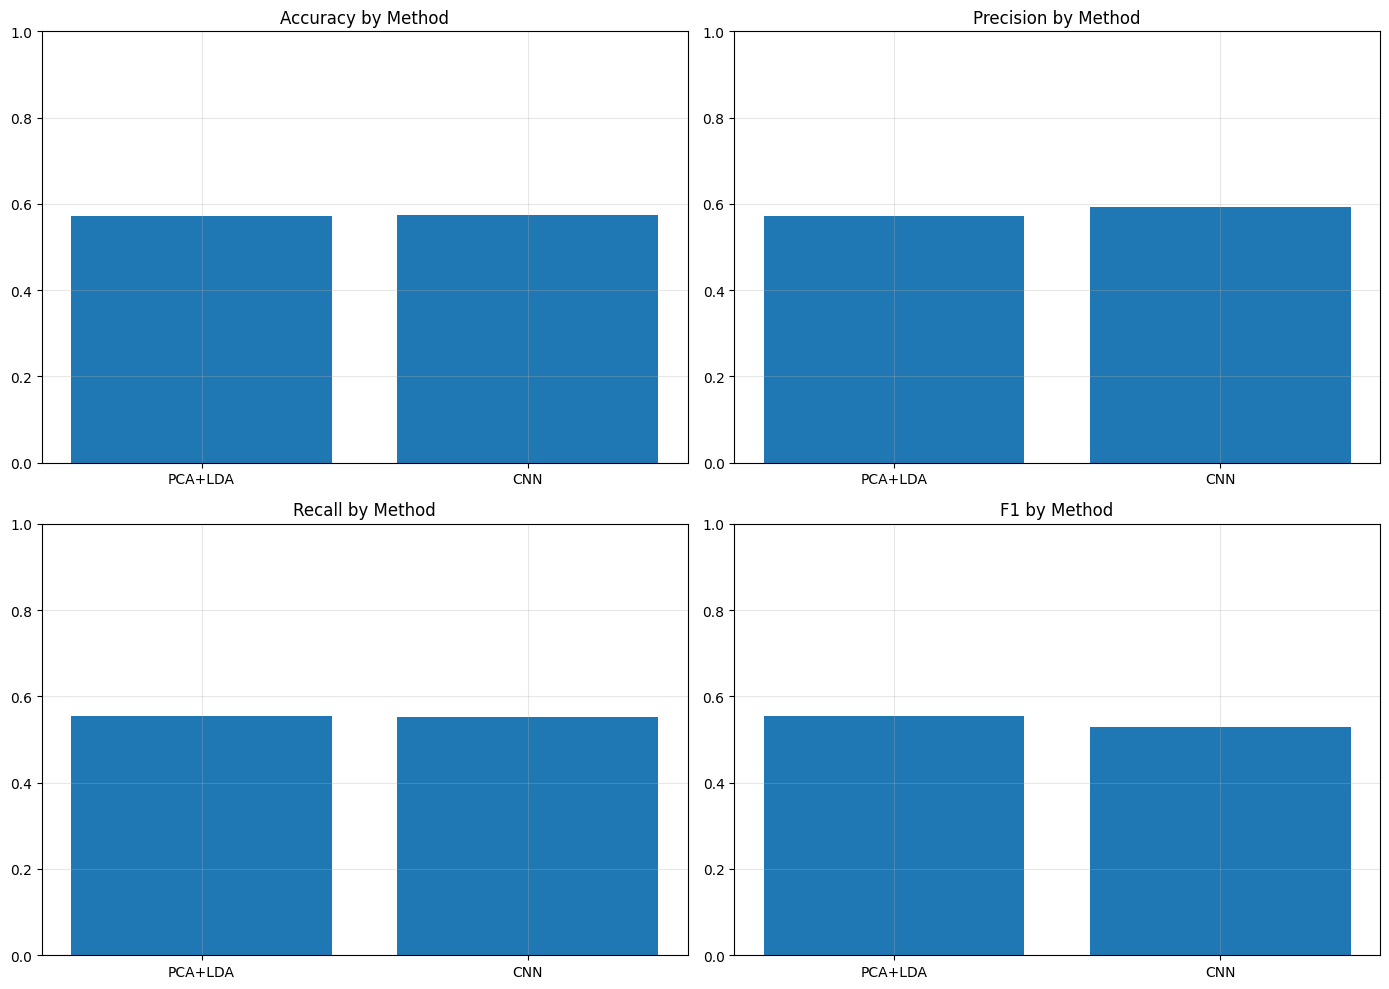

,accuracy,precision,recall,f1
PCA+LDA,0.572266,0.572935,0.555525,0.554976
CNN,0.574219,0.591795,0.551481,0.529625


In [75]:
# Optimization suggestions
def run_pipeline_optimized(X_train, y_train, X_test, y_test):
    results = {}

    # Only run fast methods & CNN
    n_components_pca = 50

    # PCA + LDA + sklearn SVM
    pca_projected, pca_components, _, mean_face, _ = pca_from_scratch(X_train, n_components_pca)
    pca_test = np.dot(X_test - np.mean(X_train, axis=0), pca_components)

    n_components_lda = min(n_components_pca, len(np.unique(y_train)) - 1)
    lda_projected, lda_components, _ = lda_from_scratch(pca_projected, y_train, n_components_lda)
    lda_test = np.dot(pca_test, lda_components)

    from sklearn.svm import SVC
    svm_lda = SVC()
    svm_lda.fit(lda_projected, y_train)
    lda_preds = svm_lda.predict(lda_test)
    results['PCA+LDA'] = evaluate_model(y_test, lda_preds)

    # CNN with early stopping
    cnn_model, cnn_preds, _ = train_cnn(X_train, y_train, X_test, y_test, epochs=10)
    results['CNN'] = evaluate_model(y_test, cnn_preds)

    return results
# Example usage of the optimized pipeline

optimized_results = run_pipeline_optimized(X_train, y_train, X_test, y_test)
visualize_results(optimized_results)

Resizing images from 100×100 to 50×50...

Testing all methods with reduced dimensions:

1. Testing PCA...
PCA Accuracy: 0.6152 | Time: 2.65s

2. Testing PCA+LDA...
PCA+LDA Accuracy: 0.5801 | Time: 0.28s

3. Testing SVD...
SVD Accuracy: 0.6152 | Time: 3.15s


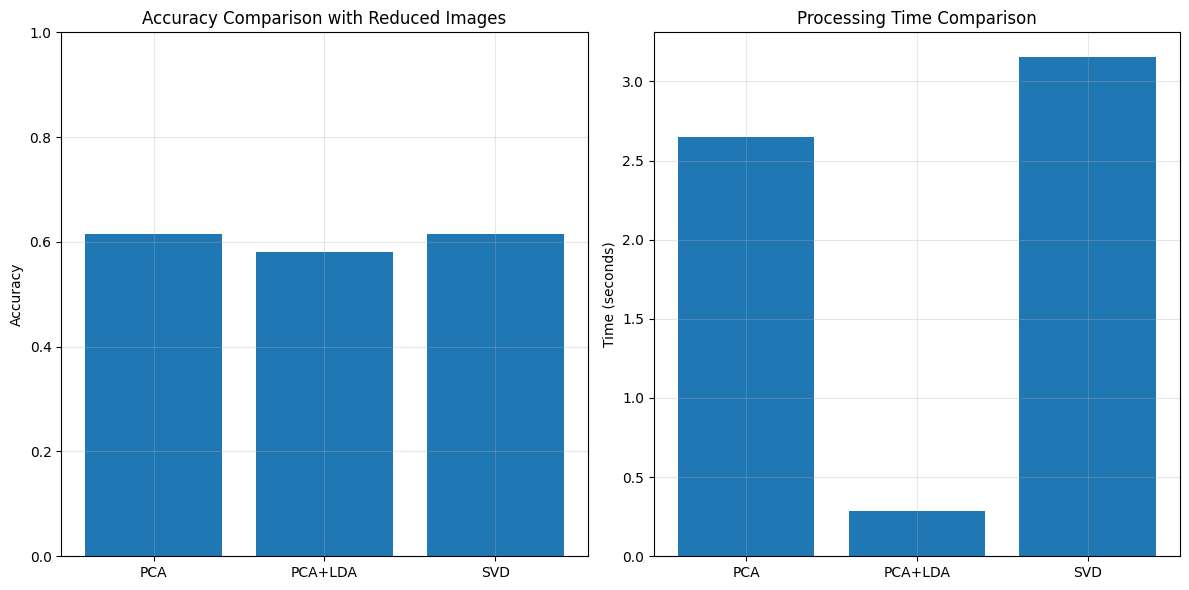

In [76]:
# def optimize_image_dimensions(X_train, y_train, X_test, y_test, target_size=50):
#     """Resize images and test all methods with reduced dimensions."""
#     from sklearn.svm import SVC
#     import time
#
#     # Reshape to image format
#     img_size = int(np.sqrt(X_train.shape[1]))
#     X_train_img = X_train.reshape(-1, img_size, img_size)
#     X_test_img = X_test.reshape(-1, img_size, img_size)
#
#     # Resize images
#     print(f"Resizing images from {img_size}×{img_size} to {target_size}×{target_size}...")
#     X_train_resized = np.array([np.array(Image.fromarray(img).resize((target_size, target_size),
#                               Image.LANCZOS)).flatten() for img in X_train_img])
#     X_test_resized = np.array([np.array(Image.fromarray(img).resize((target_size, target_size),
#                              Image.LANCZOS)).flatten() for img in X_test_img])
#
#     # Standardize data
#     from sklearn.preprocessing import StandardScaler
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train_resized)
#     X_test_scaled = scaler.transform(X_test_resized)
#
#     results = {}
#     methods = []
#
#     # Test all methods with reduced dimensions
#     print("\nTesting all methods with reduced dimensions:")
#
#     # 1. PCA only
#     print("\n1. Testing PCA...")
#     start_time = time.time()
#     n_components_pca = min(100, X_train_scaled.shape[0] - 1)
#     pca_projected, pca_components, _, mean_face, _ = pca_from_scratch(
#         X_train_scaled, n_components_pca, regularization=1e-4
#     )
#
#     X_test_centered = X_test_scaled - mean_face
#     pca_test = np.dot(X_test_centered, pca_components)
#
#     classifier = SVC(kernel='rbf', C=10, gamma='scale')
#     classifier.fit(pca_projected, y_train)
#     pca_preds = classifier.predict(pca_test)
#     pca_accuracy = np.mean(pca_preds == y_test)
#     pca_time = time.time() - start_time
#
#     methods.append("PCA")
#     results["PCA"] = {
#         "accuracy": pca_accuracy,
#         "time": pca_time,
#         "components": n_components_pca
#     }
#     print(f"PCA Accuracy: {pca_accuracy:.4f} | Time: {pca_time:.2f}s")
#
#     # 2. PCA + LDA
#     print("\n2. Testing PCA+LDA...")
#     start_time = time.time()
#     n_classes = len(np.unique(y_train))
#     n_components_lda = min(20, n_classes-1)
#
#     lda_projected, lda_components, _ = lda_from_scratch(pca_projected, y_train, n_components_lda)
#     lda_test = np.dot(pca_test, lda_components)
#
#     classifier = SVC(kernel='rbf', C=10, gamma='scale')
#     classifier.fit(lda_projected, y_train)
#     lda_preds = classifier.predict(lda_test)
#     lda_accuracy = np.mean(lda_preds == y_test)
#     lda_time = time.time() - start_time
#
#     methods.append("PCA+LDA")
#     results["PCA+LDA"] = {
#         "accuracy": lda_accuracy,
#         "time": lda_time,
#         "components": n_components_lda
#     }
#     print(f"PCA+LDA Accuracy: {lda_accuracy:.4f} | Time: {lda_time:.2f}s")
#
#     # 3. SVD
#     print("\n3. Testing SVD...")
#     start_time = time.time()
#     svd_projected, svd_components, _, mean_face_svd = svd_from_scratch(X_train_scaled, n_components_pca)
#
#     X_test_centered = X_test_scaled - mean_face_svd
#     svd_test = np.dot(X_test_centered, svd_components)
#
#     classifier = SVC(kernel='rbf', C=10, gamma='scale')
#     classifier.fit(svd_projected, y_train)
#     svd_preds = classifier.predict(svd_test)
#     svd_accuracy = np.mean(svd_preds == y_test)
#     svd_time = time.time() - start_time
#
#     methods.append("SVD")
#     results["SVD"] = {
#         "accuracy": svd_accuracy,
#         "time": svd_time,
#         "components": n_components_pca
#     }
#     print(f"SVD Accuracy: {svd_accuracy:.4f} | Time: {svd_time:.2f}s")
#
#     # Compare results
#     plt.figure(figsize=(12, 6))
#
#     plt.subplot(1, 2, 1)
#     plt.bar(methods, [results[m]["accuracy"] for m in methods])
#     plt.title('Accuracy Comparison with Reduced Images')
#     plt.ylabel('Accuracy')
#     plt.ylim(0, 1)
#     plt.grid(alpha=0.3)
#
#     plt.subplot(1, 2, 2)
#     plt.bar(methods, [results[m]["time"] for m in methods])
#     plt.title('Processing Time Comparison')
#     plt.ylabel('Time (seconds)')
#     plt.grid(alpha=0.3)
#
#     plt.tight_layout()
#     plt.show()
#
#     return X_train_scaled, X_test_scaled, results
#
# # Run with reduced dimensions (50×50)
# X_train_reduced, X_test_reduced, reduced_results = optimize_image_dimensions(
#     X_train, y_train, X_test, y_test, target_size=50
# )

Evaluating all face recognition methods...

1. Testing PCA...
PCA Accuracy: 0.5977 | Time: 4.11s

2. Testing PCA+LDA...
PCA+LDA Accuracy: 0.5684 | Time: 0.39s

3. Testing SVD...
SVD Accuracy: 0.5977 | Time: 89.80s

4. Testing SVD+LDA...
SVD+LDA Accuracy: 0.5684 | Time: 0.52s

5. Testing NMF...
NMF Accuracy: 0.4316 | Time: 24.98s

6. Testing CNN...
Epoch 1/10
65/65 [==============================] - 44s 638ms/step - loss: 3.5673 - accuracy: 0.1785 - val_loss: 3.0776 - val_accuracy: 0.1621 - lr: 1.0000e-04
Epoch 2/10
65/65 [==============================] - 42s 644ms/step - loss: 2.1787 - accuracy: 0.4102 - val_loss: 2.8638 - val_accuracy: 0.1973 - lr: 1.0000e-04
Epoch 3/10
65/65 [==============================] - 43s 655ms/step - loss: 1.6372 - accuracy: 0.5254 - val_loss: 2.6463 - val_accuracy: 0.2207 - lr: 1.0000e-04
Epoch 4/10
65/65 [==============================] - 43s 657ms/step - loss: 1.3235 - accuracy: 0.6215 - val_loss: 2.1452 - val_accuracy: 0.3965 - lr: 1.0000e-04
Epoch 5/10

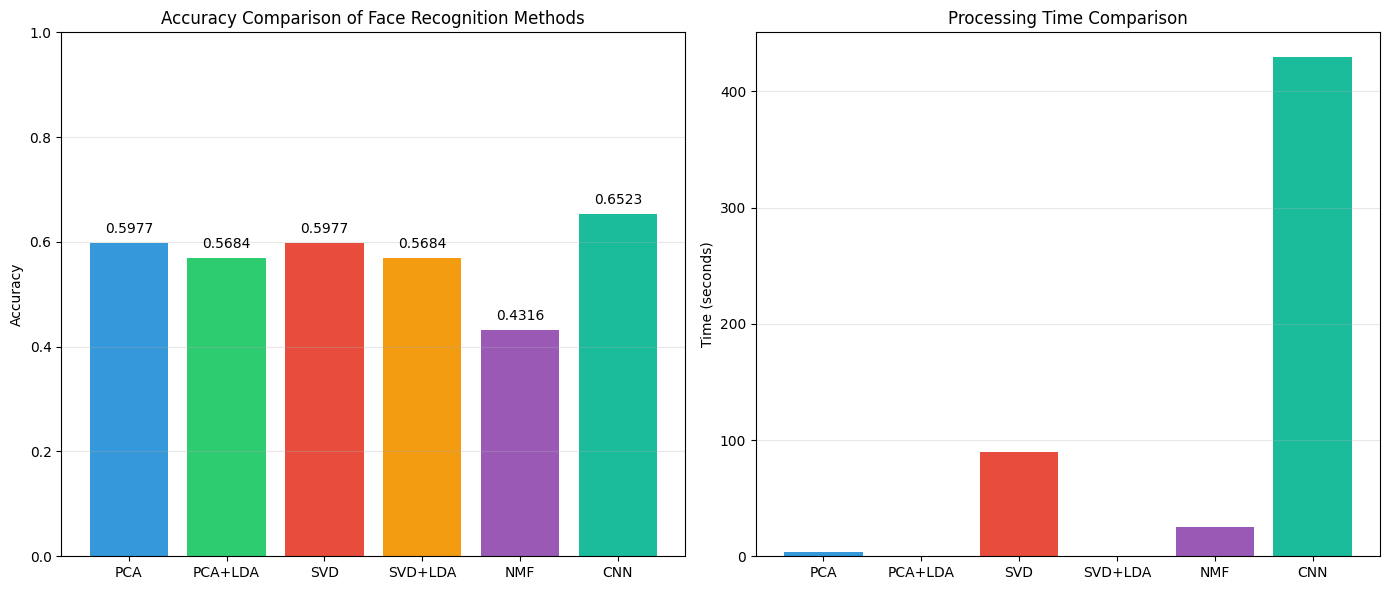


Best method: CNN with accuracy 0.6523


In [80]:
def evaluate_all_methods(X_train, y_train, X_test, y_test):
    """
    Evaluate and compare accuracy of all face recognition methods.

    Args:
        X_train, y_train: Training data and labels
        X_test, y_test: Testing data and labels

    Returns:
        Dictionary with results for all methods
    """
    from sklearn.svm import SVC
    import time

    results = {}
    methods = []

    print("Evaluating all face recognition methods...")

    # 1. PCA with SVM
    print("\n1. Testing PCA...")
    start_time = time.time()
    n_components_pca = 50
    pca_projected, pca_components, _, mean_face, _ = pca_from_scratch(X_train, n_components_pca)

    # Project test data
    X_test_centered = X_test - mean_face
    pca_test = np.dot(X_test_centered, pca_components)

    # Train classifier
    classifier = SVC(kernel='rbf', C=10, gamma='scale')
    classifier.fit(pca_projected, y_train)

    # Evaluate
    pca_preds = classifier.predict(pca_test)
    pca_accuracy = np.mean(pca_preds == y_test)
    pca_time = time.time() - start_time

    methods.append("PCA")
    results["PCA"] = {
        "accuracy": pca_accuracy,
        "time": pca_time,
        "components": n_components_pca
    }
    print(f"PCA Accuracy: {pca_accuracy:.4f} | Time: {pca_time:.2f}s")

    # 2. PCA + LDA
    print("\n2. Testing PCA+LDA...")
    start_time = time.time()
    n_classes = len(np.unique(y_train))
    n_components_lda = min(n_classes-1, n_components_pca)

    lda_projected, lda_components, _ = lda_from_scratch(pca_projected, y_train, n_components_lda)
    lda_test = np.dot(pca_test, lda_components)

    classifier = SVC(kernel='rbf', C=10, gamma='scale')
    classifier.fit(lda_projected, y_train)
    lda_preds = classifier.predict(lda_test)
    lda_accuracy = np.mean(lda_preds == y_test)
    lda_time = time.time() - start_time

    methods.append("PCA+LDA")
    results["PCA+LDA"] = {
        "accuracy": lda_accuracy,
        "time": lda_time,
        "components": n_components_lda
    }
    print(f"PCA+LDA Accuracy: {lda_accuracy:.4f} | Time: {lda_time:.2f}s")

    # 3. SVD
    print("\n3. Testing SVD...")
    start_time = time.time()
    svd_projected, svd_components, _, mean_face_svd = svd_from_scratch(X_train, n_components_pca)

    X_test_centered = X_test - mean_face_svd
    svd_test = np.dot(X_test_centered, svd_components)

    classifier = SVC(kernel='rbf', C=10, gamma='scale')
    classifier.fit(svd_projected, y_train)
    svd_preds = classifier.predict(svd_test)
    svd_accuracy = np.mean(svd_preds == y_test)
    svd_time = time.time() - start_time

    methods.append("SVD")
    results["SVD"] = {
        "accuracy": svd_accuracy,
        "time": svd_time,
        "components": n_components_pca
    }
    print(f"SVD Accuracy: {svd_accuracy:.4f} | Time: {svd_time:.2f}s")

    # 4. SVD + LDA
    print("\n4. Testing SVD+LDA...")
    start_time = time.time()

    svd_lda_projected, svd_lda_components, _ = lda_from_scratch(svd_projected, y_train, n_components_lda)
    svd_lda_test = np.dot(svd_test, svd_lda_components)

    classifier = SVC(kernel='rbf', C=10, gamma='scale')
    classifier.fit(svd_lda_projected, y_train)
    svd_lda_preds = classifier.predict(svd_lda_test)
    svd_lda_accuracy = np.mean(svd_lda_preds == y_test)
    svd_lda_time = time.time() - start_time

    methods.append("SVD+LDA")
    results["SVD+LDA"] = {
        "accuracy": svd_lda_accuracy,
        "time": svd_lda_time,
        "components": n_components_lda
    }
    print(f"SVD+LDA Accuracy: {svd_lda_accuracy:.4f} | Time: {svd_lda_time:.2f}s")

    # 5. NMF
    print("\n5. Testing NMF...")
    try:
        start_time = time.time()
        # Ensure non-negativity
        X_train_pos = np.maximum(X_train - np.min(X_train), 0)
        n_components_nmf = 30

        # Run NMF
        W_train, H = nmf_from_scratch(X_train_pos, n_components=n_components_nmf)

        # Project test data
        X_test_pos = np.maximum(X_test - np.min(X_train), 0)
        W_test = np.dot(X_test_pos, np.linalg.pinv(H))

        classifier = SVC(kernel='rbf', C=10, gamma='scale')
        classifier.fit(W_train, y_train)
        nmf_preds = classifier.predict(W_test)
        nmf_accuracy = np.mean(nmf_preds == y_test)
        nmf_time = time.time() - start_time

        methods.append("NMF")
        results["NMF"] = {
            "accuracy": nmf_accuracy,
            "time": nmf_time,
            "components": n_components_nmf
        }
        print(f"NMF Accuracy: {nmf_accuracy:.4f} | Time: {nmf_time:.2f}s")
    except Exception as e:
        print(f"Error in NMF: {e}")

    # 6. CNN
    print("\n6. Testing CNN...")
    try:
        start_time = time.time()

        # Train CNN with early stopping
        cnn_model, cnn_preds, cnn_history = train_cnn(X_train, y_train, X_test, y_test, epochs=10)

        # Calculate accuracy
        cnn_accuracy = np.mean(cnn_preds == y_test)
        cnn_time = time.time() - start_time

        methods.append("CNN")
        results["CNN"] = {
            "accuracy": cnn_accuracy,
            "time": cnn_time,
            "components": None  # CNN doesn't use components in the same way
        }
        print(f"CNN Accuracy: {cnn_accuracy:.4f} | Time: {cnn_time:.2f}s")
    except Exception as e:
        print(f"Error in CNN: {e}")

    # Visualize results
    plt.figure(figsize=(14, 6))

    # Accuracy comparison
    plt.subplot(1, 2, 1)
    accuracies = [results[m]["accuracy"] for m in methods]
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
    bars = plt.bar(methods, accuracies, color=colors[:len(methods)])
    plt.title('Accuracy Comparison of Face Recognition Methods')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{accuracies[i]:.4f}', ha='center')

    plt.grid(alpha=0.3, axis='y')

    # Processing time comparison
    plt.subplot(1, 2, 2)
    times = [results[m]["time"] for m in methods]
    plt.bar(methods, times, color=colors[:len(methods)])
    plt.title('Processing Time Comparison')
    plt.ylabel('Time (seconds)')
    plt.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Find best method
    best_method = max(results.items(), key=lambda x: x[1]["accuracy"])
    print(f"\nBest method: {best_method[0]} with accuracy {best_method[1]['accuracy']:.4f}")

    return results

# Example usage:
results = evaluate_all_methods(X_train, y_train, X_test, y_test)